In [ ]:
import numpy as np
import cv2
import torch
from google.colab.patches import cv2_imshow
from google.colab import files
print("GPU Available:", torch.cuda.is_available())
!nvidia-smi

GPU Available: True
Wed Jun 10 10:16:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.1 MB/s eta 0:00:00


In [ ]:
yolov5 = torch.hub.load('ultralytics/yolov5',
                        'yolov5s',
                        pretrained=True,
                        trust_repo=True)
print("YOLOv5 model loaded successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master


requirements: Ultralytics requirement ["urllib3>=2.6.0 ; python_version > '3.8'"] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 146ms
Prepared 1 package in 19ms
Uninstalled 1 package in 2ms
Installed 1 package in 2ms
 - urllib3==2.5.0
 + urllib3==2.7.0

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



YOLOv5 🚀 2026-6-10 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

100%|██████████| 14.1M/14.1M [00:00<00:00, 376MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


YOLOv5 model loaded successfully.


In [ ]:
uploaded = files.upload()

Saving image.jpg to image.jpg


## 1

Uploaded image: image.jpg


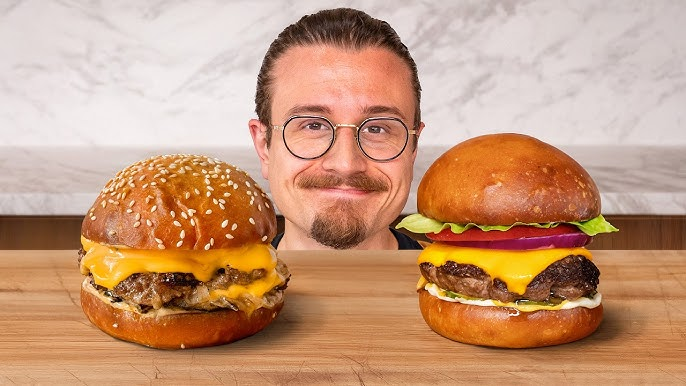

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:903: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 386x686 1 person, 2 sandwichs
Speed: 2.6ms pre-process, 16.7ms inference, 40.9ms NMS per image at shape (1, 3, 384, 640)


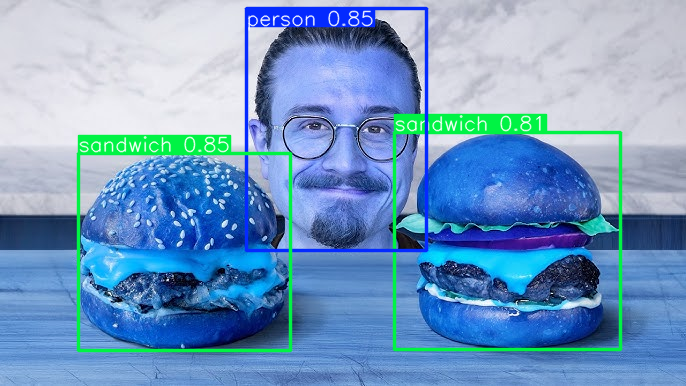


Output image saved as output_result1.png


In [18]:
image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

image = cv2.imread(image_path)
cv2_imshow(image)

results = yolov5(image)
objects = results.xyxyn[0].detach().cpu().numpy()
results.print()
results.show()

output_image = image.copy()
h, w, _ = output_image.shape
objects[:, 0:4] = objects[:, 0:4] * [w, h, w, h]

classes = yolov5.names

for obj in objects:
  if obj[-2] > 0.5:
    tl, br = obj[0:2].astype('int'), obj[2:4].astype('int')
    cv2.rectangle(output_image, tuple(tl), tuple(br), (0, 255, 0), 2)

output_filename = "output_result1.png"
cv2.imwrite(output_filename, output_image)
print(f"\nOutput image saved as {output_filename}")

## 2

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2026-6-10 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5x summary: 444 layers, 86705005 parameters, 0 gradients, 205.5 GFLOPs
Adding AutoShape... 


Uploaded image: image.jpg


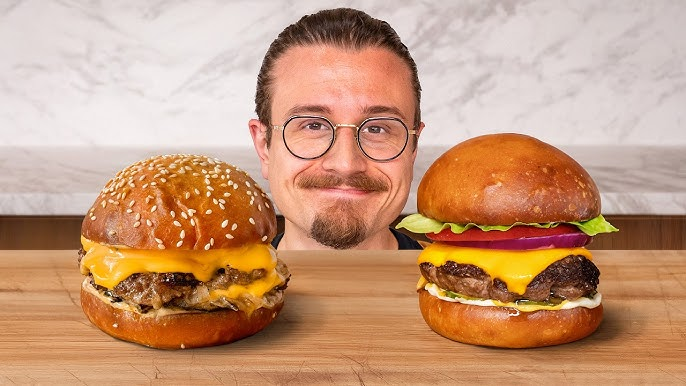

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:903: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 386x686 1 person, 2 sandwichs
Speed: 2.7ms pre-process, 16.6ms inference, 41.2ms NMS per image at shape (1, 3, 384, 640)



Detected objects:
sandwich: 0.85
person: 0.85
sandwich: 0.81

Output image saved as output_result2.png


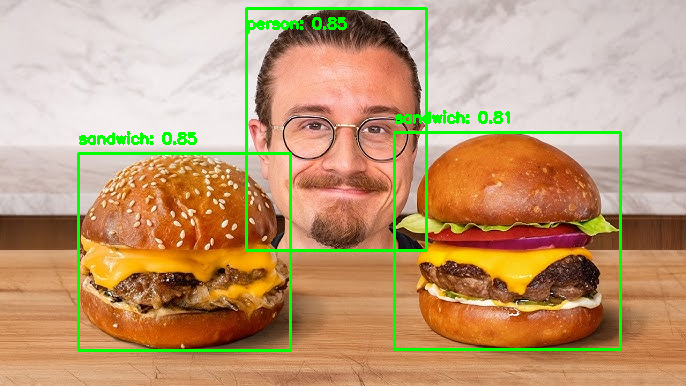

In [17]:
yolov5 = torch.hub.load('ultralytics/yolov5', 'yolov5x')

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

image = cv2.imread(image_path)
cv2_imshow(image)
results = yolov5(image)

results.print()
objects = results.xyxyn[0].detach().cpu().numpy()
output_image = image.copy()
h, w, _ = output_image.shape
objects[:, 0:4] = objects[:, 0:4] * [w, h, w, h]
classes = yolov5.names
confidence_threshold = 0.50

print("\nDetected objects:")

for obj in objects:
    confidence = obj[4]
    class_id = int(obj[5])
    if confidence >= confidence_threshold:
        class_name = classes[class_id]
        print(f"{class_name}: {confidence:.2f}")

        x1, y1, x2, y2 = obj[0:4].astype(int)
        cv2.rectangle(output_image,
                      (x1, y1),
                      (x2, y2),
                      (0, 255, 0),
                      2)
        label = f"{class_name}: {confidence:.2f}"

        text_y = y1 - 10 if y1 - 10 > 10 else y1 + 20
        cv2.putText(output_image,
                    label,
                    (x1, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2)

output_filename = "output_result2.png"
cv2.imwrite(output_filename, output_image)
print(f"\nOutput image saved as {output_filename}")

cv2_imshow(output_image)